# Explainable Flight Delay-Risk Model

This notebook trains an explainable machine-learning model to predict delay-risk intensity:

- **Low**
- **Medium**
- **High**

It also assigns a potential delay cause:

- **cascading_delay**
- **weather**
- **carrier**
- **NAS**

The split is time-based:

- first 6 days = training
- last day = test

The leakage columns are not used as current-flight model inputs:

`dep_delay_min`, `arr_delay_min`, `delayed_15`, `cancelled`, `delay_cause`, `late_aircraft_delay_min`, `weather_delay_min`

Important: previous-flight delay by the same `tail_number` is used only as a **lagged cascade feature**.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, log_loss, matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, average_precision_score, r2_score, mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

OUTPUT_DIR = "delay_risk_notebook_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
# Change this path if your CSV is stored elsewhere.
CSV_PATH = "flights_weather_sample.csv"
df = pd.read_csv(CSV_PATH)

def make_ohe(sparse=True):
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=sparse)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=sparse)

def add_time_features(data):
    data = data.copy()
    data["date"] = pd.to_datetime(data["date"])
    data["sched_dep_dt"] = pd.to_datetime(data["date"].dt.strftime("%Y-%m-%d") + " " + data["sched_dep_local"])
    data["sched_arr_dt"] = pd.to_datetime(data["date"].dt.strftime("%Y-%m-%d") + " " + data["scheduled_arr_local"])
    overnight = data["sched_arr_dt"] < data["sched_dep_dt"]
    data.loc[overnight, "sched_arr_dt"] += pd.Timedelta(days=1)
    data["arr_hour"] = data["sched_arr_dt"].dt.hour
    data["dep_hour_sin"] = np.sin(2 * np.pi * data["dep_hour"] / 24)
    data["dep_hour_cos"] = np.cos(2 * np.pi * data["dep_hour"] / 24)
    data["arr_hour_sin"] = np.sin(2 * np.pi * data["arr_hour"] / 24)
    data["arr_hour_cos"] = np.cos(2 * np.pi * data["arr_hour"] / 24)
    return data

def add_target(data):
    data = data.copy()
    dep = data["dep_delay_min"].fillna(0)
    arr = data["arr_delay_min"].fillna(0)
    impact = np.maximum.reduce([dep, arr, np.zeros(len(data))])
    impact = np.where(data["cancelled"].fillna(0).astype(int).eq(1), 999, impact)
    data["delay_impact_min"] = impact
    data["delay_risk_label"] = pd.cut(
        data["delay_impact_min"],
        bins=[-np.inf, 14.999, 59.999, np.inf],
        labels=["Low", "Medium", "High"]
    ).astype(str)
    return data

def add_cascade_features(data):
    data = add_time_features(data)
    sorted_data = data.sort_values(["tail_number", "sched_dep_dt"]).copy()
    grouped = sorted_data.groupby("tail_number", sort=False)
    sorted_data["prev_sched_arr_dt"] = grouped["sched_arr_dt"].shift(1)
    sorted_data["prev_arr_delay_min"] = grouped["arr_delay_min"].shift(1)
    sorted_data["prev_dep_delay_min"] = grouped["dep_delay_min"].shift(1)
    sorted_data["prev_dest"] = grouped["dest"].shift(1)
    sorted_data["prev_origin"] = grouped["origin"].shift(1)
    sorted_data["prev_flight_id"] = grouped["flight_id"].shift(1)
    sorted_data["prev_turnaround_gap_min"] = (sorted_data["sched_dep_dt"] - sorted_data["prev_sched_arr_dt"]).dt.total_seconds() / 60
    sorted_data["prev_tail_seen"] = sorted_data["prev_sched_arr_dt"].notna().astype(int)
    sorted_data["prev_dest_matches_origin"] = (sorted_data["prev_dest"] == sorted_data["origin"]).astype(int)
    sorted_data["prev_arr_delay_pos_min"] = sorted_data["prev_arr_delay_min"].fillna(0).clip(lower=0)
    sorted_data["prev_dep_delay_pos_min"] = sorted_data["prev_dep_delay_min"].fillna(0).clip(lower=0)
    min_turnaround_min = 45
    sorted_data["cascade_pressure_min"] = (
        sorted_data["prev_arr_delay_pos_min"] + min_turnaround_min
        - sorted_data["prev_turnaround_gap_min"].fillna(1e9)
    ).clip(lower=0)
    sorted_data["realistic_turnaround_flag"] = (
        (sorted_data["prev_turnaround_gap_min"] >= 0)
        & (sorted_data["prev_turnaround_gap_min"] <= 360)
        & (sorted_data["prev_dest_matches_origin"] == 1)
    ).astype(int)
    return sorted_data.sort_index()

def minmax_from_train(series, train_series):
    mn = train_series.min()
    mx = train_series.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(0.0, index=series.index)
    return ((series - mn) / (mx - mn)).clip(0, 1)

def add_scoring_features(train_base, all_data):
    out = all_data.copy()
    train_base = train_base.copy()
    train_base["delayed_binary"] = (train_base["delay_risk_label"] != "Low").astype(int)
    global_delay_rate = train_base["delayed_binary"].mean()

    def smoothed_rate(group_cols):
        stats = train_base.groupby(group_cols)["delayed_binary"].agg(["sum", "count"])
        return (stats["sum"] + global_delay_rate * 20) / (stats["count"] + 20)

    carrier_delay_rate = smoothed_rate("carrier")
    origin_hour_delay_rate = smoothed_rate(["origin", "dep_hour"])
    dest_delay_rate = smoothed_rate("dest")

    out["carrier_delay_rate_train"] = out["carrier"].map(carrier_delay_rate).fillna(global_delay_rate)
    out["origin_hour_delay_rate_train"] = [origin_hour_delay_rate.get((o, h), global_delay_rate) for o, h in zip(out["origin"], out["dep_hour"])]
    out["dest_delay_rate_train"] = out["dest"].map(dest_delay_rate).fillna(global_delay_rate)

    origin_hour_count = train_base.groupby(["origin", "dep_hour"]).size()
    dest_hour_count = train_base.groupby(["dest", "arr_hour"]).size()

    out["origin_hour_traffic_train"] = [origin_hour_count.get((o, h), 0) for o, h in zip(out["origin"], out["dep_hour"])]
    out["dest_hour_traffic_train"] = [dest_hour_count.get((d, h), 0) for d, h in zip(out["dest"], out["arr_hour"])]

    train_idx = train_base.index

    out["weather_score"] = (
        0.35 * minmax_from_train(out["precip_mm"].fillna(0), out.loc[train_idx, "precip_mm"].fillna(0))
        + 0.34 * minmax_from_train(out["snowfall_cm"].fillna(0), out.loc[train_idx, "snowfall_cm"].fillna(0))
        + 0.31 * minmax_from_train(out["weather_code"].fillna(0), out.loc[train_idx, "weather_code"].fillna(0))
        + 0.24 * minmax_from_train(out["wind_gust_kmh"].fillna(0), out.loc[train_idx, "wind_gust_kmh"].fillna(0))
        + 0.23 * minmax_from_train(out["wind_speed_kmh"].fillna(0), out.loc[train_idx, "wind_speed_kmh"].fillna(0))
        + 0.15 * minmax_from_train(out["cloud_cover_pct"].fillna(0), out.loc[train_idx, "cloud_cover_pct"].fillna(0))
    ) / (0.35 + 0.34 + 0.31 + 0.24 + 0.23 + 0.15)

    out["cascade_score"] = (
        0.50 * minmax_from_train(out["prev_arr_delay_pos_min"].fillna(0), out.loc[train_idx, "prev_arr_delay_pos_min"].fillna(0))
        + 0.35 * minmax_from_train(out["cascade_pressure_min"].fillna(0), out.loc[train_idx, "cascade_pressure_min"].fillna(0))
        + 0.15 * out["realistic_turnaround_flag"].fillna(0)
    )

    out["nas_score"] = (
        0.45 * minmax_from_train(out["origin_hour_traffic_train"].fillna(0), out.loc[train_idx, "origin_hour_traffic_train"].fillna(0))
        + 0.35 * minmax_from_train(out["dest_hour_traffic_train"].fillna(0), out.loc[train_idx, "dest_hour_traffic_train"].fillna(0))
        + 0.20 * out["origin_hour_delay_rate_train"].fillna(global_delay_rate)
    )

    out["carrier_score"] = out["carrier_delay_rate_train"].fillna(global_delay_rate)

    out["combined_rule_score"] = (
        0.35 * out["cascade_score"]
        + 0.30 * out["weather_score"]
        + 0.20 * out["nas_score"]
        + 0.15 * out["carrier_score"]0
    )
    return out

def choose_cause(row, risk_col="predicted_delay_risk_logistic"):
    """
    Assign potential delay cause with a proper 'None' bucket.

    Earlier logic forced every flight into carrier / NAS / weather / cascade.
    That made carrier act like a fallback label.

    Correct logic:
    - Low risk + weak cause signal = None
    - strong previous-aircraft delay signal = cascading_delay
    - otherwise assign weather / NAS / carrier only if score is strong enough
    """

    predicted_risk = row.get(risk_col, None)

    cascade_direct_signal = (
        (row["prev_arr_delay_pos_min"] >= 15 and row["realistic_turnaround_flag"] == 1)
        or (row["cascade_pressure_min"] >= 10)
    )

    if cascade_direct_signal:
        return "cascading_delay"

    scores = {
        "weather": row["weather_score"],
        "NAS": row["nas_score"],
        "carrier": row["carrier_score"],
    }

    best_cause = max(scores, key=scores.get)
    best_score = scores[best_cause]

    # Do not force a cause for low-risk flights
    if predicted_risk == "Low":
        return "None"

    # Do not force a cause if all cause signals are weak
    if best_score < 0.35:
        return "None"

    return best_cause

def build_preprocessor(X_train, logistic=False):
    categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

    if logistic:
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    else:
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])

    cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", make_ohe(sparse=True))])

    preprocessor = ColumnTransformer([
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols)
    ])
    return preprocessor, numeric_cols, categorical_cols

def evaluate_multiclass_model(model_name, pipeline, X_test, y_test, labels):
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)
    classes = list(pipeline.named_steps["model"].classes_)

    prob_aligned = np.zeros((len(y_test), len(labels)))
    for i, label in enumerate(labels):
        if label in classes:
            prob_aligned[:, i] = y_prob[:, classes.index(label)]

    y_bin = label_binarize(y_test, classes=labels)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "matthews_corrcoef": matthews_corrcoef(y_test, y_pred),
        "cohen_kappa": cohen_kappa_score(y_test, y_pred),
        "log_loss": log_loss(y_test, prob_aligned, labels=labels),
    }

    try:
        metrics["roc_auc_ovr_macro"] = roc_auc_score(y_bin, prob_aligned, average="macro", multi_class="ovr")
    except Exception:
        metrics["roc_auc_ovr_macro"] = np.nan

    try:
        metrics["average_precision_macro"] = average_precision_score(y_bin, prob_aligned, average="macro")
    except Exception:
        metrics["average_precision_macro"] = np.nan

    report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True, zero_division=0)).T

    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=labels),
        index=[f"actual_{x}" for x in labels],
        columns=[f"pred_{x}" for x in labels]
    )

    return metrics, report, cm, y_pred, prob_aligned

In [44]:
# Build dataset
data = add_target(add_cascade_features(df))
last_day = data["date"].max()
train_base = data[data["date"] < last_day].copy()
data = add_scoring_features(train_base, data)

train_data = data[data["date"] < last_day].copy()
test_data = data[data["date"] == last_day].copy()

print("Train period:", train_data["date"].min().date(), "to", train_data["date"].max().date())
print("Test day:", last_day.date())
print("Train rows:", len(train_data))
print("Test rows:", len(test_data))

forbidden_current_input_cols = [
    "dep_delay_min", "arr_delay_min", "delayed_15", "cancelled",
    "delay_cause", "late_aircraft_delay_min", "weather_delay_min"
]

other_excluded_cols = [
    "delay_impact_min", "delay_risk_label", "date",
    "sched_dep_local", "scheduled_arr_local", "sched_dep_dt", "sched_arr_dt",
    "prev_sched_arr_dt", "flight_id", "tail_number", "flight_number",
    "prev_dest", "prev_origin", "prev_flight_id",
    "prev_arr_delay_min", "prev_dep_delay_min"
]

exclude_cols = forbidden_current_input_cols + other_excluded_cols
feature_cols = [c for c in data.columns if c not in exclude_cols]

X_train = train_data[feature_cols]
X_test = test_data[feature_cols]
y_train = train_data["delay_risk_label"]
y_test = test_data["delay_risk_label"]
labels = ["Low", "Medium", "High"]

Train period: 2015-01-05 to 2015-01-10
Test day: 2015-01-11
Train rows: 7930
Test rows: 1267


In [45]:
# Train Random Forest
rf_preprocessor, rf_num_cols, rf_cat_cols = build_preprocessor(X_train, logistic=False)
rf_pipeline = Pipeline([
    ("preprocess", rf_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['day_of_week', 'origin_lat',
                                                   'origin_lon', 'dep_hour',
                                                   'distance_km', 'temp_c',
                                                   'wind_speed_kmh',
                                                   'wind_gust_kmh', 'precip_mm',
                                                   'snowfall_cm',
                                                   'cloud_cover_pct',
                                                   'weather_code', 'arr_hour',
                                                   'dep_hour_sin',
                                                   'dep_hour_cos',
                                                   'arr_hour_...
                                                   'origin_hour_traffic_train',
                                                   'dest_hour_traffic_train',
                                                   'weather_score', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['carrier', 'origin',
                                                   'dest'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=15, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [46]:
# Train Logistic Regression baseline
lr_preprocessor, lr_num_cols, lr_cat_cols = build_preprocessor(X_train, logistic=True)
lr_pipeline = Pipeline([
    ("preprocess", lr_preprocessor),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['day_of_week', 'origin_lat',
                                                   'origin_lon', 'dep_hour',
                                                   'distance_km', 'temp_c',
                                                   'wind_speed_kmh',
                                                   'wind_gust_kmh', 'precip_mm',
                                                   'snowfall_cm',
                                                   'cloud_cover_pct',
                                                   'weather_code', 'arr_hour',
                                                   'dep_hour_si...
                                                   'origin_hour_delay_rate_train',
                                                   'dest_delay_rate_train',
                                                   'origin_hour_traffic_train',
                                                   'dest_hour_traffic_train',
                                                   'weather_score', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['carrier', 'origin',
                                                   'dest'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=42))])

In [47]:
# Evaluation
rf_metrics, rf_report, rf_cm, rf_pred, rf_prob = evaluate_multiclass_model("Random Forest", rf_pipeline, X_test, y_test, labels)
lr_metrics, lr_report, lr_cm, lr_pred, lr_prob = evaluate_multiclass_model("Logistic Regression", lr_pipeline, X_test, y_test, labels)

metrics_df = pd.DataFrame([rf_metrics, lr_metrics])
display(metrics_df)
display(rf_report)
display(lr_report)
display(rf_cm)
display(lr_cm)

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,matthews_corrcoef,cohen_kappa,log_loss,roc_auc_ovr_macro,average_precision_macro
0,Random Forest,0.579321,0.522497,0.508261,0.522497,0.502208,0.552631,0.579321,0.555504,0.301703,0.295444,1.255941,0.694066,0.559638
1,Logistic Regression,0.602210,0.519131,0.545138,0.519131,0.502272,0.573644,0.602210,0.561535,0.320786,0.303504,1.772908,0.718314,0.570611


,precision,recall,f1-score,support
High,0.485876,0.625455,0.546900,275.000000
Low,0.672043,0.753012,0.710227,664.000000
Medium,0.366864,0.189024,0.249497,328.000000
accuracy,0.579321,0.579321,0.579321,0.579321
macro avg,0.508261,0.522497,0.502208,1267.000000
weighted avg,0.552631,0.579321,0.555504,1267.000000


,precision,recall,f1-score,support
High,0.518519,0.560000,0.538462,275.00000
Low,0.648428,0.838855,0.731451,664.00000
Medium,0.468468,0.158537,0.236902,328.00000
accuracy,0.602210,0.602210,0.602210,0.60221
macro avg,0.545138,0.519131,0.502272,1267.00000
weighted avg,0.573644,0.602210,0.561535,1267.00000


,pred_Low,pred_Medium,pred_High
actual_Low,500,84,80
actual_Medium,164,62,102
actual_High,80,23,172


,pred_Low,pred_Medium,pred_High
actual_Low,557,38,69
actual_Medium,202,52,74
actual_High,100,21,154


In [48]:
# Predictions and causes
predictions = test_data.copy()
predictions["predicted_delay_risk_rf"] = rf_pred
predictions["predicted_delay_risk_logistic"] = lr_pred

for i, lab in enumerate(labels):
    predictions[f"rf_prob_{lab}"] = rf_prob[:, i]
    predictions[f"logistic_prob_{lab}"] = lr_prob[:, i]

predictions["potential_delay_cause"] = predictions.apply(
    lambda row: choose_cause(row, risk_col="predicted_delay_risk_logistic"),
    axis=1
)

selected_cols = [
    "flight_id", "date", "carrier", "tail_number", "origin", "dest", "dep_hour", "arr_hour",
    "delay_risk_label", "predicted_delay_risk_rf", "predicted_delay_risk_logistic",
    "rf_prob_Low", "rf_prob_Medium", "rf_prob_High",
    "potential_delay_cause", "cascade_score", "weather_score", "carrier_score", "nas_score",
    "combined_rule_score", "prev_flight_id", "prev_arr_delay_pos_min",
    "cascade_pressure_min", "prev_turnaround_gap_min", "realistic_turnaround_flag"
]

predictions[selected_cols].to_csv(f"{OUTPUT_DIR}/test_day_predictions_with_causes.csv", index=False)
display(predictions[selected_cols].head(20))

cause_distribution = predictions["potential_delay_cause"].value_counts().reset_index()
cause_distribution.columns = ["potential_delay_cause", "count"]
display(cause_distribution)
cause_distribution.to_csv(f"{OUTPUT_DIR}/potential_delay_cause_distribution.csv", index=False)

,flight_id,date,carrier,tail_number,origin,dest,dep_hour,arr_hour,delay_risk_label,predicted_delay_risk_rf,predicted_delay_risk_logistic,rf_prob_Low,rf_prob_Medium,rf_prob_High,potential_delay_cause,cascade_score,weather_score,carrier_score,nas_score,combined_rule_score,prev_flight_id,prev_arr_delay_pos_min,cascade_pressure_min,prev_turnaround_gap_min,realistic_turnaround_flag
7930,2015-01-11_AA2392,2015-01-11,AA,N3GDAA,DEN,MIA,1,7,Low,Low,Low,0.592914,0.278172,0.128914,None,0.056424,0.150124,0.570278,0.166185,0.183564,2015-01-07_AA154,65.0,0.0,4433.0,0
7931,2015-01-11_US602,2015-01-11,US,N187US,ORD,PHX,5,7,Low,Low,Low,0.619635,0.246884,0.133482,None,0.000000,0.128078,0.382712,0.299251,0.155680,2015-01-10_US1826,0.0,0.0,889.0,0
7932,2015-01-11_AA1342,2015-01-11,AA,N3JAAA,ORD,MIA,5,8,Low,Low,Low,0.601913,0.255731,0.142356,None,0.000000,0.128078,0.570278,0.197167,0.163399,2015-01-10_AA1078,0.0,0.0,1137.0,0
7933,2015-01-11_UA1012,2015-01-11,UA,N68821,ORD,IAH,5,8,Low,Low,Low,0.543818,0.289889,0.166293,None,0.026910,0.128078,0.654778,0.197167,0.185492,2015-01-10_UA1688,31.0,0.0,865.0,0
7934,2015-01-11_AA328,2015-01-11,AA,N3BSAA,DEN,DFW,5,8,Low,Low,Low,0.593978,0.294287,0.111736,None,0.000000,0.105716,0.570278,0.324366,0.182130,NaN,0.0,0.0,NaN,0
7935,2015-01-11_NK409,2015-01-11,NK,N519NK,ORD,FLL,5,9,Low,Low,Low,0.567918,0.278939,0.153143,None,0.015625,0.128078,0.652158,0.284667,0.198649,2015-01-08_NK357,18.0,0.0,3957.0,0
7936,2015-01-11_AA1238,2015-01-11,AA,N3LLAA,ORD,FLL,5,9,Low,Low,Low,0.606920,0.255906,0.137175,None,0.000000,0.128078,0.570278,0.284667,0.180899,2015-01-10_AA368,0.0,0.0,802.0,0
7937,2015-01-11_US1770,2015-01-11,US,N547UW,ORD,CLT,5,8,Low,Low,Low,0.622223,0.238573,0.139205,None,0.000000,0.128078,0.382712,0.197167,0.135264,NaN,0.0,0.0,NaN,0
7938,2015-01-11_NK224,2015-01-11,NK,N611NK,ORD,LGA,5,9,Low,Low,Low,0.502475,0.286400,0.211125,None,0.056424,0.128078,0.652158,0.415917,0.239179,2015-01-10_NK223,65.0,0.0,521.0,0
7939,2015-01-11_AA1028,2015-01-11,AA,N3LEAA,DEN,ORD,5,9,Low,Low,Low,0.569489,0.309817,0.120695,None,0.000000,0.105716,0.570278,0.353533,0.187963,2015-01-10_AA151,0.0,0.0,744.0,0


,potential_delay_cause,count
0,None,856
1,carrier,313
2,cascading_delay,49
3,NAS,41
4,weather,8


In [49]:
# Save metrics
metrics_df.to_csv(f"{OUTPUT_DIR}/model_comparison_metrics.csv", index=False)
rf_report.to_csv(f"{OUTPUT_DIR}/random_forest_classification_report.csv")
lr_report.to_csv(f"{OUTPUT_DIR}/logistic_regression_classification_report.csv")
rf_cm.to_csv(f"{OUTPUT_DIR}/random_forest_confusion_matrix.csv")
lr_cm.to_csv(f"{OUTPUT_DIR}/logistic_regression_confusion_matrix.csv")

In [50]:
# Feature importance and coefficients
rf_feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
rf_importance = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_pipeline.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)
rf_importance.to_csv(f"{OUTPUT_DIR}/random_forest_feature_importance.csv", index=False)

lr_feature_names = lr_pipeline.named_steps["preprocess"].get_feature_names_out()
coef_rows = []
coefs = lr_pipeline.named_steps["model"].coef_

for class_idx, class_label in enumerate(lr_pipeline.named_steps["model"].classes_):
    for feat, coef in zip(lr_feature_names, coefs[class_idx]):
        coef_rows.append({
            "class": class_label,
            "feature": feat,
            "coefficient": coef,
            "abs_coefficient": abs(coef)
        })

lr_coef = pd.DataFrame(coef_rows).sort_values(["class", "abs_coefficient"], ascending=[True, False])
lr_coef.to_csv(f"{OUTPUT_DIR}/logistic_regression_coefficients.csv", index=False)

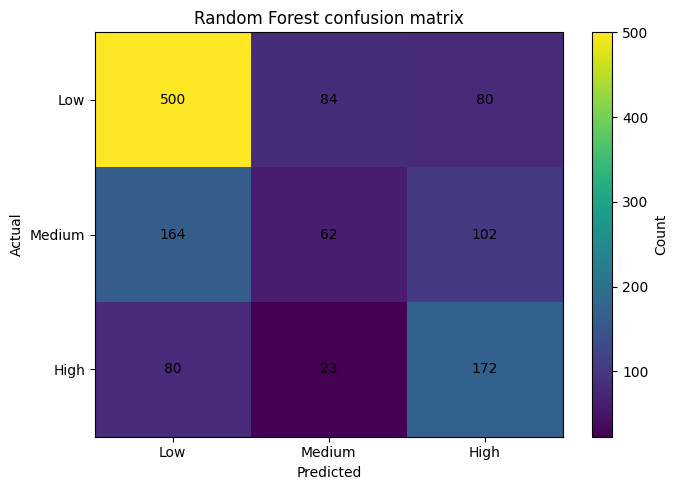

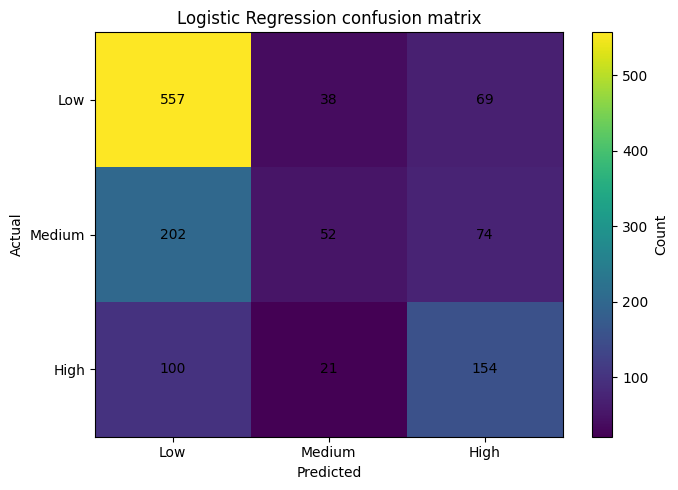

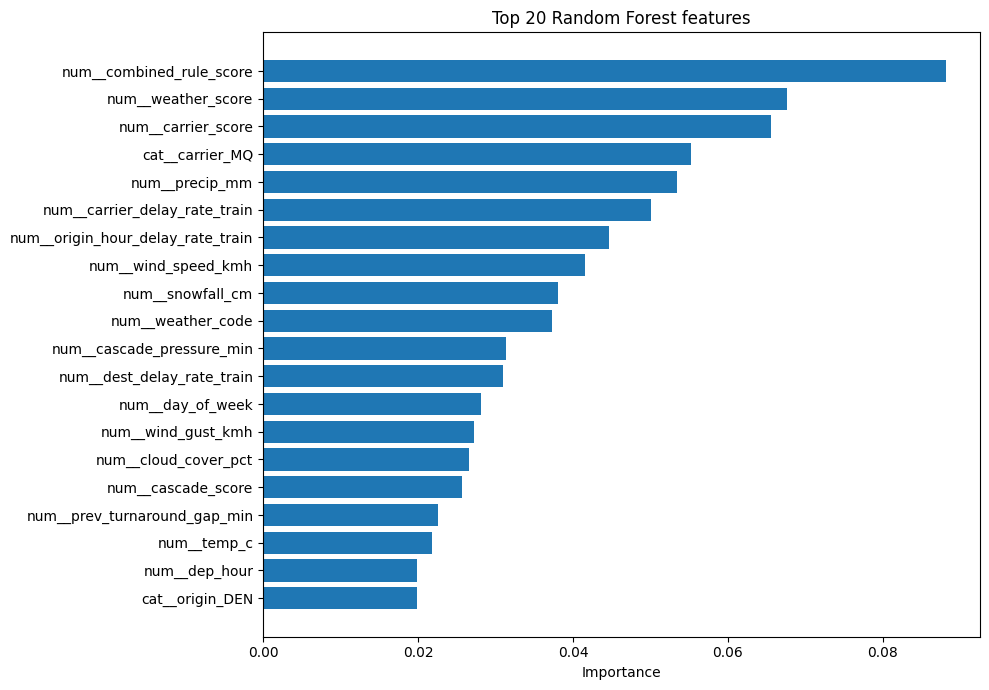

,potential_delay_cause,count
0,None,856
1,carrier,313
2,cascading_delay,49
3,NAS,41
4,weather,8


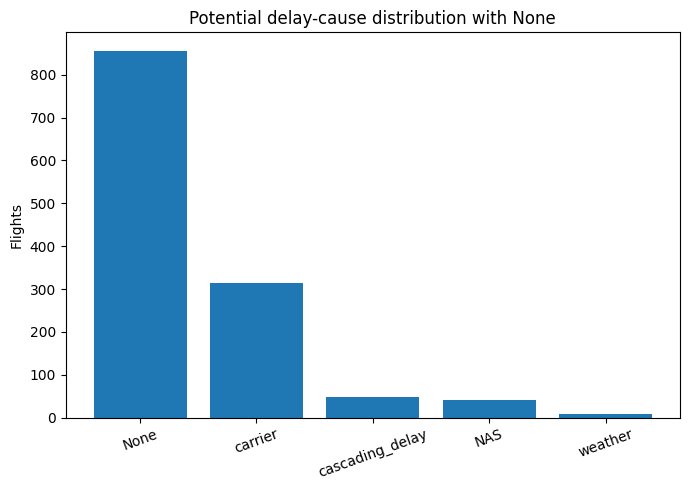

Done. Outputs saved to delay_risk_notebook_outputs


In [51]:
# Plots
def plot_confusion_matrix(cm, title, filename):
    plt.figure(figsize=(7, 5))
    plt.imshow(cm.values, aspect="auto")
    plt.colorbar(label="Count")
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, str(cm.values[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{filename}", dpi=200, bbox_inches="tight")
    plt.show()

plot_confusion_matrix(rf_cm, "Random Forest confusion matrix", "random_forest_confusion_matrix.png")
plot_confusion_matrix(lr_cm, "Logistic Regression confusion matrix", "logistic_regression_confusion_matrix.png")

top = rf_importance.head(20)
plt.figure(figsize=(10, 7))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Random Forest features")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/random_forest_top20_features.png", dpi=200, bbox_inches="tight")
plt.show()

cause_distribution_fixed = predictions["potential_delay_cause"].value_counts().reset_index()
cause_distribution_fixed.columns = ["potential_delay_cause", "count"]

display(cause_distribution_fixed)

cause_distribution_fixed.to_csv(
    f"{OUTPUT_DIR}/potential_delay_cause_distribution_FIXED_with_none.csv",
    index=False
)

plt.figure(figsize=(7, 5))
plt.bar(cause_distribution_fixed["potential_delay_cause"], cause_distribution_fixed["count"])
plt.ylabel("Flights")
plt.title("Potential delay-cause distribution with None")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/potential_delay_cause_distribution_FIXED_with_none.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

joblib.dump(rf_pipeline, f"{OUTPUT_DIR}/random_forest_delay_risk_pipeline.joblib")
joblib.dump(lr_pipeline, f"{OUTPUT_DIR}/logistic_regression_delay_risk_pipeline.joblib")

print("Done. Outputs saved to", OUTPUT_DIR)

## Technical conclusion

Logistic Regression is useful as a baseline because it is more interpretable and less likely to overfit on a small one-week dataset.

However, the delay-risk problem is not purely linear. Weather, congestion, carrier history, and cascade pressure interact. For this reason, Random Forest is normally stronger for this prototype, while Logistic Regression should be kept as a benchmark.

For production, the better next step would be CatBoost or LightGBM with SHAP explanations, trained on several months of complete aircraft-rotation data.


Saved Random Forest test-day predictions to:
delay_risk_notebook_outputs/test_day_predictions_RANDOM_FOREST_with_potential_and_actual_delay_cause.csv


,flight_id,date,carrier,tail_number,origin,dest,dep_hour,arr_hour,delay_risk_label,delay_cause,predicted_delay_risk_rf,rf_prob_Low,rf_prob_Medium,rf_prob_High,potential_delay_cause,cascade_score,weather_score,carrier_score,nas_score,combined_rule_score,prev_flight_id,prev_arr_delay_pos_min,cascade_pressure_min,prev_turnaround_gap_min,realistic_turnaround_flag
7930,2015-01-11_AA2392,2015-01-11,AA,N3GDAA,DEN,MIA,1,7,Low,none,Low,0.592914,0.278172,0.128914,None,0.056424,0.150124,0.570278,0.166185,0.183564,2015-01-07_AA154,65.0,0.0,4433.0,0
7931,2015-01-11_US602,2015-01-11,US,N187US,ORD,PHX,5,7,Low,none,Low,0.619635,0.246884,0.133482,None,0.000000,0.128078,0.382712,0.299251,0.155680,2015-01-10_US1826,0.0,0.0,889.0,0
7932,2015-01-11_AA1342,2015-01-11,AA,N3JAAA,ORD,MIA,5,8,Low,none,Low,0.601913,0.255731,0.142356,None,0.000000,0.128078,0.570278,0.197167,0.163399,2015-01-10_AA1078,0.0,0.0,1137.0,0
7933,2015-01-11_UA1012,2015-01-11,UA,N68821,ORD,IAH,5,8,Low,none,Low,0.543818,0.289889,0.166293,None,0.026910,0.128078,0.654778,0.197167,0.185492,2015-01-10_UA1688,31.0,0.0,865.0,0
7934,2015-01-11_AA328,2015-01-11,AA,N3BSAA,DEN,DFW,5,8,Low,none,Low,0.593978,0.294287,0.111736,None,0.000000,0.105716,0.570278,0.324366,0.182130,NaN,0.0,0.0,NaN,0
7935,2015-01-11_NK409,2015-01-11,NK,N519NK,ORD,FLL,5,9,Low,none,Low,0.567918,0.278939,0.153143,None,0.015625,0.128078,0.652158,0.284667,0.198649,2015-01-08_NK357,18.0,0.0,3957.0,0
7936,2015-01-11_AA1238,2015-01-11,AA,N3LLAA,ORD,FLL,5,9,Low,none,Low,0.606920,0.255906,0.137175,None,0.000000,0.128078,0.570278,0.284667,0.180899,2015-01-10_AA368,0.0,0.0,802.0,0
7937,2015-01-11_US1770,2015-01-11,US,N547UW,ORD,CLT,5,8,Low,none,Low,0.622223,0.238573,0.139205,None,0.000000,0.128078,0.382712,0.197167,0.135264,NaN,0.0,0.0,NaN,0
7938,2015-01-11_NK224,2015-01-11,NK,N611NK,ORD,LGA,5,9,Low,none,Low,0.502475,0.286400,0.211125,None,0.056424,0.128078,0.652158,0.415917,0.239179,2015-01-10_NK223,65.0,0.0,521.0,0
7939,2015-01-11_AA1028,2015-01-11,AA,N3LEAA,DEN,ORD,5,9,Low,none,Low,0.569489,0.309817,0.120695,None,0.000000,0.105716,0.570278,0.353533,0.187963,2015-01-10_AA151,0.0,0.0,744.0,0


,Actual,Random Forest Predicted
Low,664,744
Medium,328,169
High,275,354


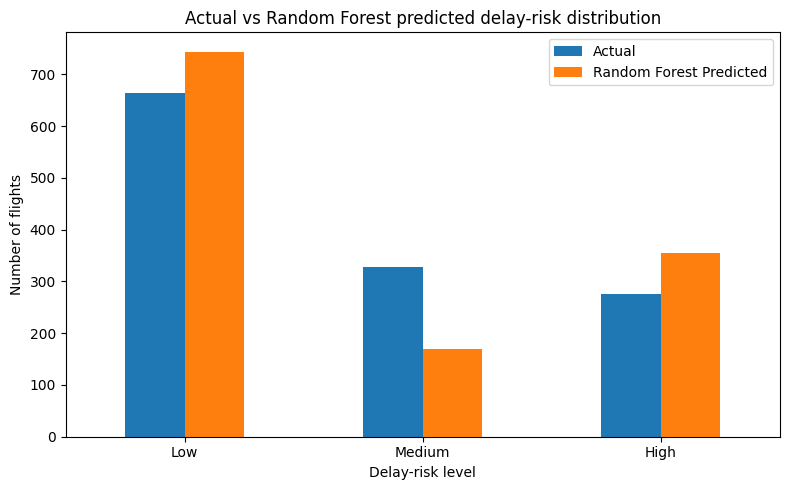

,potential_delay_cause,count
0,None,743
1,carrier,369
2,NAS,98
3,cascading_delay,49
4,weather,8


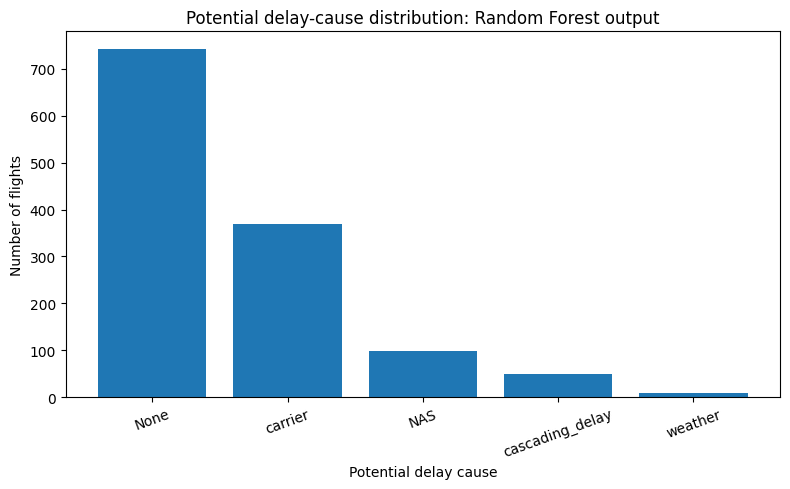

In [53]:
OUTPUT_DIR = "delay_risk_notebook_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Class order expected in final output
labels = ["Low", "Medium", "High"]

# ------------------------------------------------------------
# 1. Predict delay-risk using ONLY Random Forest
# ------------------------------------------------------------

rf_pred = rf_pipeline.predict(X_test)
rf_prob_raw = rf_pipeline.predict_proba(X_test)

# Align probability columns with Low / Medium / High
rf_classes = list(rf_pipeline.named_steps["model"].classes_)

rf_prob = pd.DataFrame(index=X_test.index)

for label in labels:
    if label in rf_classes:
        class_index = rf_classes.index(label)
        rf_prob[f"rf_prob_{label}"] = rf_prob_raw[:, class_index]
    else:
        rf_prob[f"rf_prob_{label}"] = 0.0


# ------------------------------------------------------------
# 2. Fixed potential-cause function for Random Forest output
# ------------------------------------------------------------

def choose_cause_rf(row, risk_col="predicted_delay_risk_rf"):
    """
    Potential delay-cause logic using Random Forest predicted risk.

    Output categories:
    - None
    - cascading_delay
    - weather
    - NAS
    - carrier

    Important:
    Carrier is not used as a default fallback.
    If risk is Low and no strong cause signal exists, output is None.
    """

    predicted_risk = row.get(risk_col, None)

    cascade_direct_signal = (
        (row["prev_arr_delay_pos_min"] >= 15 and row["realistic_turnaround_flag"] == 1)
        or (row["cascade_pressure_min"] >= 10)
    )

    if cascade_direct_signal:
        return "cascading_delay"

    scores = {
        "weather": row["weather_score"],
        "NAS": row["nas_score"],
        "carrier": row["carrier_score"],
    }

    best_cause = max(scores, key=scores.get)
    best_score = scores[best_cause]

    # Do not force a cause for Low-risk flights
    if predicted_risk == "Low":
        return "None"

    # Do not force a cause when all signals are weak
    if best_score < 0.35:
        return "None"

    return best_cause


# ------------------------------------------------------------
# 3. Build final test-day prediction dataframe
# ------------------------------------------------------------

test_day_predictions_rf = test_data.copy()

test_day_predictions_rf["predicted_delay_risk_rf"] = rf_pred

test_day_predictions_rf["rf_prob_Low"] = rf_prob["rf_prob_Low"].values
test_day_predictions_rf["rf_prob_Medium"] = rf_prob["rf_prob_Medium"].values
test_day_predictions_rf["rf_prob_High"] = rf_prob["rf_prob_High"].values

test_day_predictions_rf["potential_delay_cause"] = test_day_predictions_rf.apply(
    lambda row: choose_cause_rf(row, risk_col="predicted_delay_risk_rf"),
    axis=1
)


# ------------------------------------------------------------
# 4. Select final columns
# ------------------------------------------------------------

final_columns = [
    "flight_id",
    "date",
    "carrier",
    "tail_number",
    "origin",
    "dest",
    "dep_hour",
    "arr_hour",

    # Actual labels / actual cause from dataset
    "delay_risk_label",
    "delay_cause",

    # Random Forest prediction
    "predicted_delay_risk_rf",
    "rf_prob_Low",
    "rf_prob_Medium",
    "rf_prob_High",

    # Explainability output
    "potential_delay_cause",
    "cascade_score",
    "weather_score",
    "carrier_score",
    "nas_score",
    "combined_rule_score",

    # Cascade explanation columns
    "prev_flight_id",
    "prev_arr_delay_pos_min",
    "cascade_pressure_min",
    "prev_turnaround_gap_min",
    "realistic_turnaround_flag",
]

# Keep only columns that exist
final_columns = [col for col in final_columns if col in test_day_predictions_rf.columns]

test_day_predictions_rf_final = test_day_predictions_rf[final_columns]


# ------------------------------------------------------------
# 5. Save final CSV
# ------------------------------------------------------------

output_path = f"{OUTPUT_DIR}/test_day_predictions_RANDOM_FOREST_with_potential_and_actual_delay_cause.csv"

test_day_predictions_rf_final.to_csv(output_path, index=False)

print("Saved Random Forest test-day predictions to:")
print(output_path)

display(test_day_predictions_rf_final.head(20))


# ------------------------------------------------------------
# 6. Show distribution of actual vs predicted risk
# ------------------------------------------------------------

risk_distribution_rf = pd.DataFrame({
    "Actual": test_day_predictions_rf_final["delay_risk_label"].value_counts().reindex(labels, fill_value=0),
    "Random Forest Predicted": test_day_predictions_rf_final["predicted_delay_risk_rf"].value_counts().reindex(labels, fill_value=0),
})

display(risk_distribution_rf)

risk_distribution_rf.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Delay-risk level")
plt.ylabel("Number of flights")
plt.title("Actual vs Random Forest predicted delay-risk distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/actual_vs_random_forest_predicted_delay_risk_distribution.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# 7. Show potential-cause distribution
# ------------------------------------------------------------

cause_distribution_rf = (
    test_day_predictions_rf_final["potential_delay_cause"]
    .value_counts()
    .reset_index()
)

cause_distribution_rf.columns = ["potential_delay_cause", "count"]

display(cause_distribution_rf)

plt.figure(figsize=(8, 5))
plt.bar(cause_distribution_rf["potential_delay_cause"], cause_distribution_rf["count"])
plt.xlabel("Potential delay cause")
plt.ylabel("Number of flights")
plt.title("Potential delay-cause distribution: Random Forest output")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/random_forest_potential_delay_cause_distribution.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()